# Title + Objective (Markdown)

Create new features and freeze final list

# Feature Engineering

## Objective
This notebook demonstrates the feature engineering phase for the EcoType project.

We will:

- load the cleaned dataset
- apply deterministic feature engineering using `src/features/build_features.py`
- inspect newly created features
- compare distributions before and after engineering
- build a baseline feature-importance view
- save feature reports for documentation and downstream modeling

## Why this notebook matters
The purpose of this notebook is validation and documentation.
The actual reusable feature-engineering logic lives in:

- `src/features/build_features.py`

This ensures the same transformations can be applied consistently to training, test, and inference data.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from src.features.build_features import build_features, get_feature_definitions
from src.features.selection import get_baseline_features_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
project_root = Path.cwd().resolve().parents[0]

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

raw_interim_file = project_root / "data" / "interim" / "forest_cover_cleaned.csv"
processed_dir = project_root / "data" / "processed"
reports_dir = project_root / "reports" / "feature_engineering"
docs_dir = project_root / "docs"

engineered_file = processed_dir / "forest_cover_engineered.csv"
feature_summary_csv = reports_dir / "feature_summary.csv"
feature_importance_csv = reports_dir / "baseline_feature_importance.csv"
NOTEBOOK_REPORT_MD = reports_dir / "feature_engineering_report.md"

TARGET_COLUMN = "cover_type"

reports_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)
docs_dir.mkdir(parents=True, exist_ok=True)

# Load Clean Splits (Code)

Load X_train/X_test + y_train/y_test

In [3]:
df = pd.read_csv(raw_interim_file)

print("Input shape:", df.shape)
df.head()

Input shape: (145890, 13)


,elevation,aspect,slope,horizontal_distance_to_hydrology,vertical_distance_to_hydrology,horizontal_distance_to_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,horizontal_distance_to_fire_points,cover_type,wilderness_area,soil_type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   elevation                           145890 non-null  int64 
 1   aspect                              145890 non-null  int64 
 2   slope                               145890 non-null  int64 
 3   horizontal_distance_to_hydrology    145890 non-null  int64 
 4   vertical_distance_to_hydrology      145890 non-null  int64 
 5   horizontal_distance_to_roadways     145890 non-null  int64 
 6   hillshade_9am                       145890 non-null  int64 
 7   hillshade_noon                      145890 non-null  int64 
 8   hillshade_3pm                       145890 non-null  int64 
 9   horizontal_distance_to_fire_points  145890 non-null  int64 
 10  cover_type                          145890 non-null  object
 11  wilderness_area                     145

# Baseline Feature Set Snapshot (Code)

Print original columns

Save original column list for comparison

In [5]:
org_cols = df.columns
print(org_cols)

Index(['elevation', 'aspect', 'slope', 'horizontal_distance_to_hydrology',
       'vertical_distance_to_hydrology', 'horizontal_distance_to_roadways',
       'hillshade_9am', 'hillshade_noon', 'hillshade_3pm',
       'horizontal_distance_to_fire_points', 'cover_type', 'wilderness_area',
       'soil_type'],
      dtype='object')


# Define Feature Engineering Functions (Code)

Create add_features(df) placeholder

Inside: add each engineered feature (one by one)

In [6]:
df_engineered = build_features(df)

print("Original Shape: ", df.shape)
print("Engineered Shape: ", df_engineered.shape)

Original Shape:  (145890, 13)
Engineered Shape:  (145890, 26)


In [7]:
original_cols = set(df.columns)
engineered_cols = set(df_engineered.columns)

new_features = [col for col in df_engineered.columns if col not in original_cols]

print("Number of engineered features:", len(new_features))
new_features

Number of engineered features: 13


['aspect_sin',
 'aspect_cos',
 'hydrology_distance',
 'vertical_distance_to_hydrology_abs',
 'hillshade_mean',
 'hillshade_range',
 'hillshade_std',
 'elevation_slope_interaction',
 'elevation_slope_ratio',
 'road_fire_gap',
 'road_fire_ratio',
 'hydrology_fire_ratio',
 'hydrology_road_ratio']

In [8]:
feature_defs = get_feature_definitions()

feature_defs_df = pd.DataFrame(
    {
        "feature": list(feature_defs.keys()),
        "definition": list(feature_defs.values()),
    }
)

feature_defs_df

,feature,definition
0,aspect_sin,Sine transform of aspect in radians to represe...
1,aspect_cos,Cosine transform of aspect in radians to repre...
2,hydrology_distance,Euclidean distance to hydrology computed from ...
3,vertical_distance_to_hydrology_abs,"Absolute vertical distance to hydrology, ignor..."
4,hillshade_mean,"Mean hillshade across 9am, noon, and 3pm."
5,hillshade_range,Difference between maximum and minimum hillsha...
6,hillshade_std,Standard deviation of hillshade values across ...
7,elevation_slope_interaction,Interaction term between elevation and slope.
8,elevation_slope_ratio,Elevation divided by slope magnitude to captur...
9,road_fire_gap,Absolute difference between horizontal distanc...


In [9]:
df_engineered[new_features].head()

,aspect_sin,aspect_cos,hydrology_distance,vertical_distance_to_hydrology_abs,hillshade_mean,hillshade_range,hillshade_std,elevation_slope_interaction,elevation_slope_ratio,road_fire_gap,road_fire_ratio,hydrology_fire_ratio,hydrology_road_ratio
0,0.777146,0.629320,258.000000,0,200.333333,84,45.654500,7788,865.333045,5769,0.081223,0.041089,0.505882
1,0.829038,0.559193,212.084889,6,202.000000,84,44.799554,5180,1294.999353,5835,0.062651,0.034056,0.543590
2,0.656059,-0.754710,275.769832,65,202.333333,103,58.346665,25236,311.555521,2941,0.519523,0.043784,0.084277
3,0.422618,-0.906308,269.235956,118,199.333333,116,66.972631,50130,154.722214,3121,0.497504,0.038963,0.078317
4,0.707107,0.707107,153.003268,1,201.333333,84,45.003704,5190,1297.499351,5781,0.063351,0.024789,0.391304


# Summary Statistics

In [10]:
compare_cols = [
    "aspect",
    "slope",
    "horizontal_distance_to_hydrology",
    "vertical_distance_to_hydrology",
    "hillshade_9am",
    "hillshade_noon",
    "hillshade_3pm",
]

available_compare_cols = [col for col in compare_cols if col in df.columns]

before_summary = df[available_compare_cols].describe().T
after_summary = df_engineered[new_features].describe().T

print("Original selected features summary:")
display(before_summary)

print("Engineered features summary:")
display(after_summary)

Original selected features summary:


,count,mean,std,min,25%,50%,75%,max
aspect,145890.0,141.127418,107.719296,0.0,54.0,108.0,217.0,360.0
slope,145890.0,11.925574,6.319326,0.0,7.0,11.0,15.0,61.0
horizontal_distance_to_hydrology,145890.0,251.824738,192.473899,0.0,95.0,212.0,362.0,1343.0
vertical_distance_to_hydrology,145890.0,34.554322,41.215776,-146.0,7.0,23.0,51.0,554.0
hillshade_9am,145890.0,217.368106,21.590298,0.0,207.0,222.0,232.0,254.0
hillshade_noon,145890.0,224.874748,16.084851,99.0,216.0,226.0,236.0,254.0
hillshade_3pm,145890.0,139.788203,31.311690,0.0,121.0,140.0,159.0,248.0


Engineered features summary:


,count,mean,std,min,25%,50%,75%,max
aspect_sin,145890.0,3.097200e-01,6.402777e-01,-1.000000,-0.190809,0.529919,0.882948,1.000000e+00
aspect_cos,145890.0,1.796804e-01,6.795873e-01,-1.000000,-0.453990,0.325568,0.829038,1.000000e+00
hydrology_distance,145890.0,2.559178e+02,1.945783e+02,0.000000,98.234414,216.667949,368.069287,1.356940e+03
vertical_distance_to_hydrology_abs,145890.0,3.662148e+01,3.939045e+01,0.000000,9.000000,25.000000,52.000000,5.540000e+02
hillshade_mean,145890.0,1.940104e+02,1.172222e+01,102.666667,188.000000,195.666667,202.000000,2.136667e+02
hillshade_range,145890.0,9.409112e+01,3.116421e+01,15.000000,72.000000,90.000000,111.000000,2.540000e+02
hillshade_std,145890.0,5.079894e+01,1.688523e+01,7.549834,37.634204,49.692387,61.500678,1.338743e+02
elevation_slope_interaction,145890.0,3.407287e+04,1.759609e+04,0.000000,21189.000000,31966.500000,44175.000000,1.668960e+05
elevation_slope_ratio,145890.0,4.860878e+06,1.189299e+08,43.499999,187.374988,263.909067,388.624951,3.379000e+09
road_fire_gap,145890.0,1.619414e+03,1.321933e+03,0.000000,566.000000,1183.500000,2481.000000,6.017000e+03


# Plot Original Feature Distributions

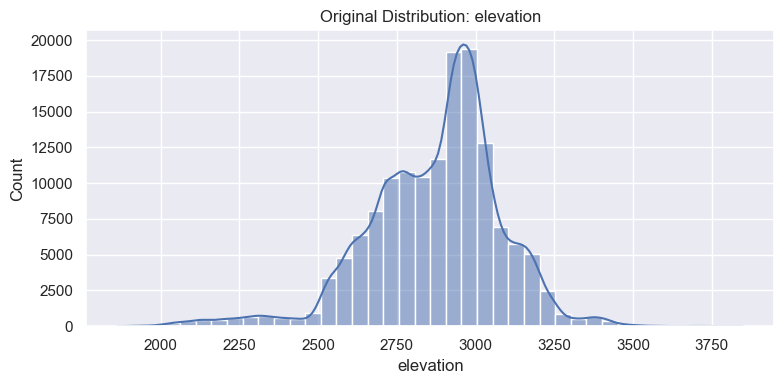

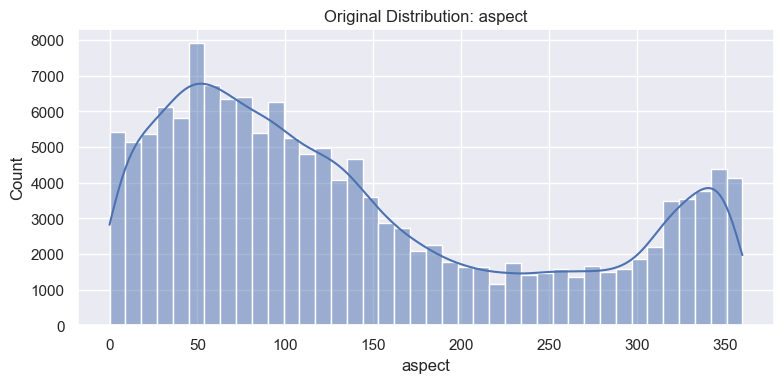

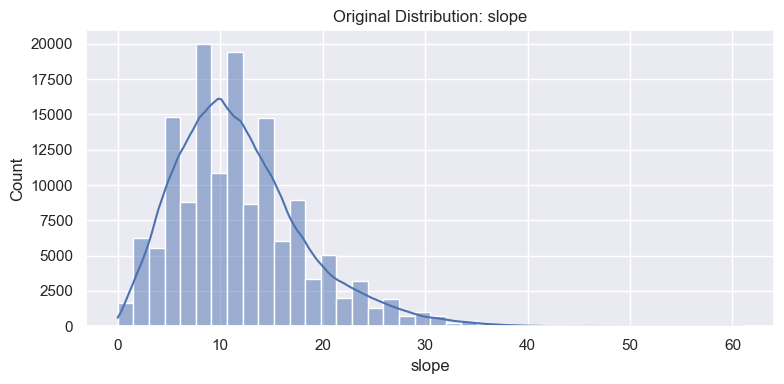

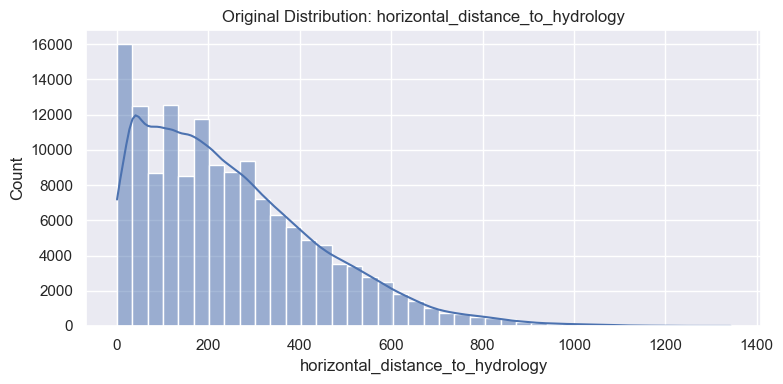

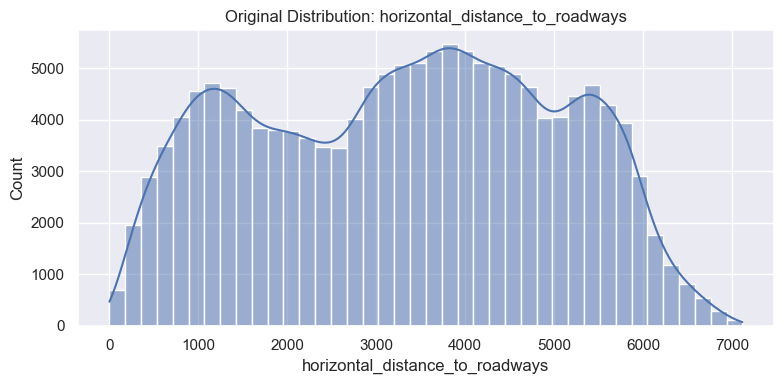

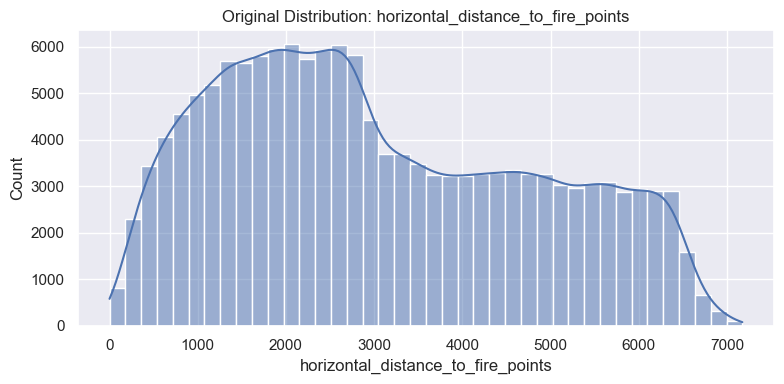

In [11]:
original_plot_cols = [
    "elevation",
    "aspect",
    "slope",
    "horizontal_distance_to_hydrology",
    "horizontal_distance_to_roadways",
    "horizontal_distance_to_fire_points",
]

original_plot_cols = [col for col in original_plot_cols if col in df.columns]

for col in original_plot_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Original Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Plot Engineered Feature Distributions

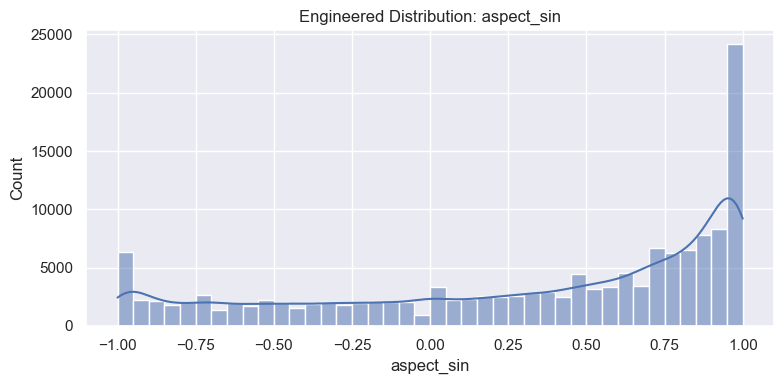

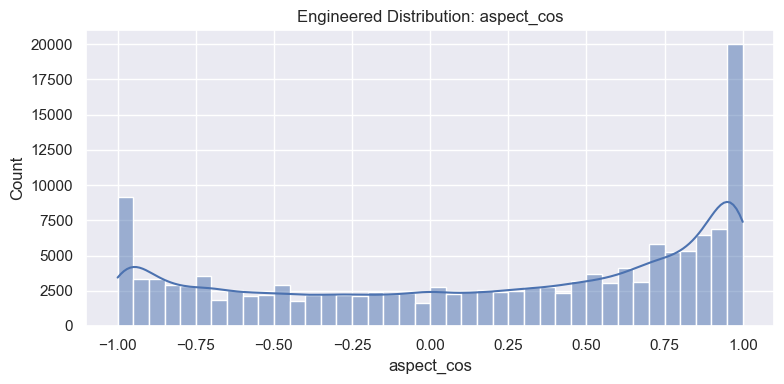

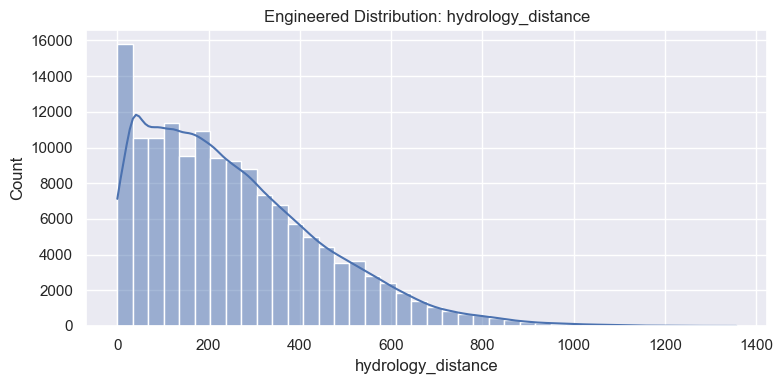

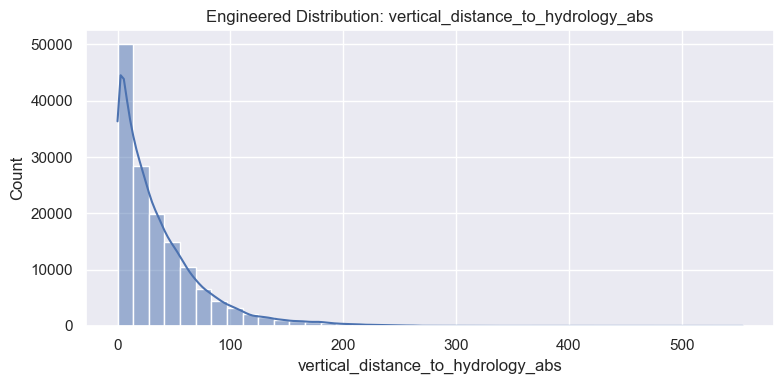

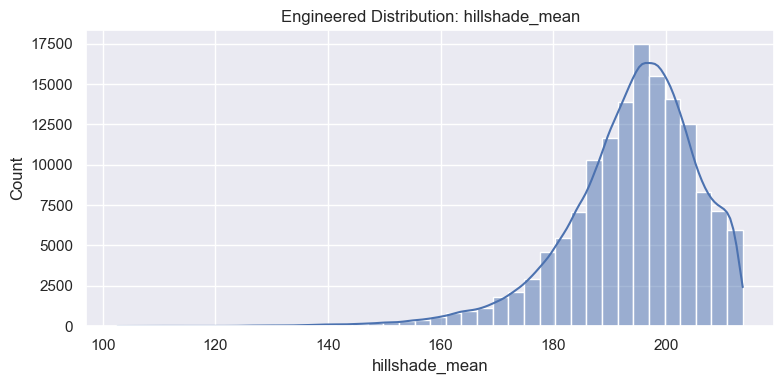

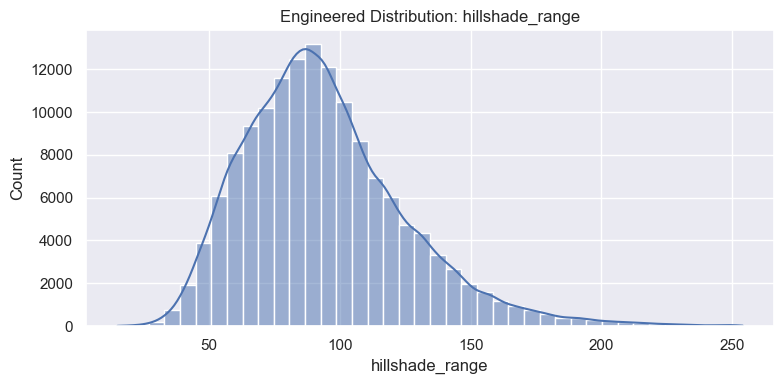

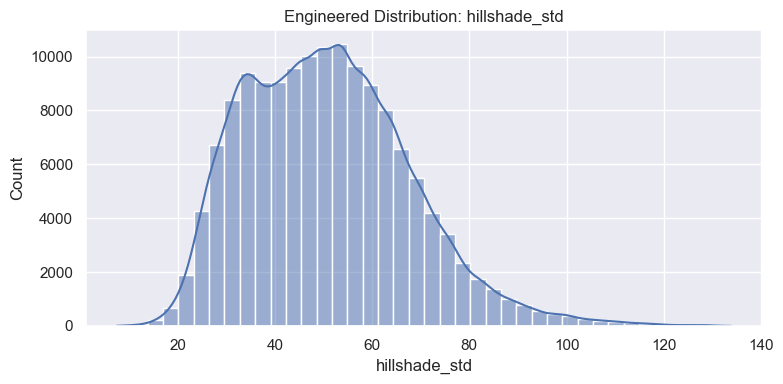

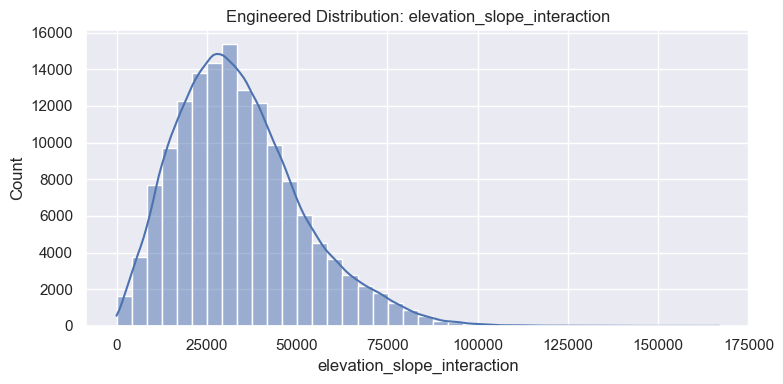

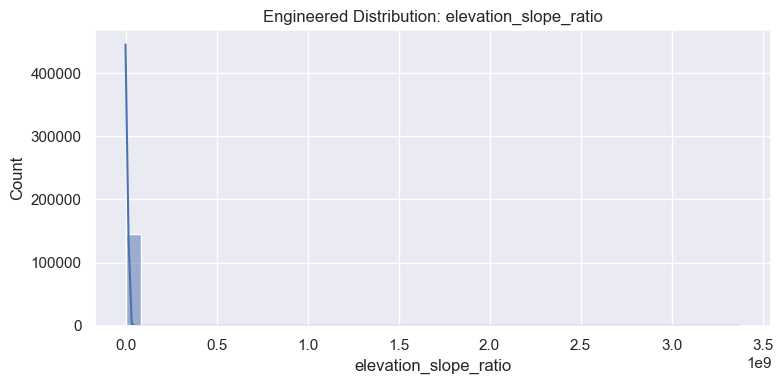

In [12]:
engineered_plot_cols = [
    "aspect_sin",
    "aspect_cos",
    "hydrology_distance",
    "vertical_distance_to_hydrology_abs",
    "hillshade_mean",
    "hillshade_range",
    "hillshade_std",
    "elevation_slope_interaction",
    "elevation_slope_ratio",
]

engineered_plot_cols = [col for col in engineered_plot_cols if col in df_engineered.columns]

for col in engineered_plot_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_engineered[col], bins=40, kde=True)
    plt.title(f"Engineered Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Example Comparison Plots

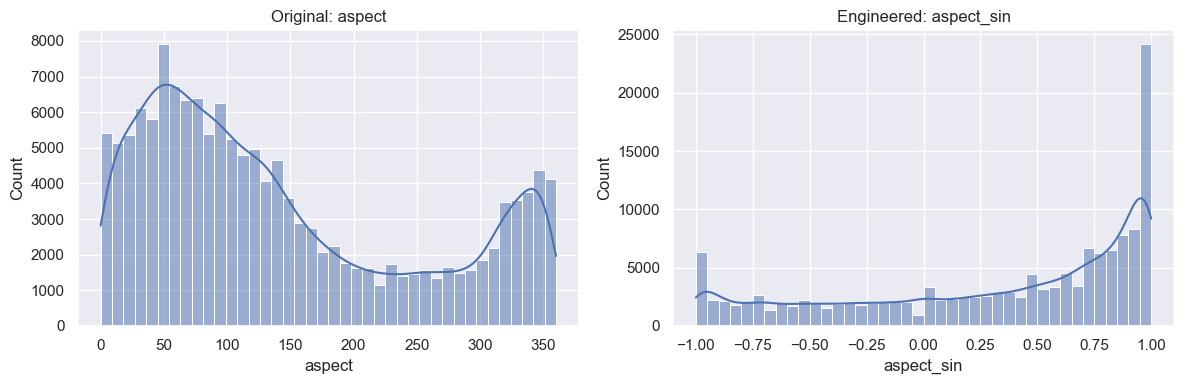

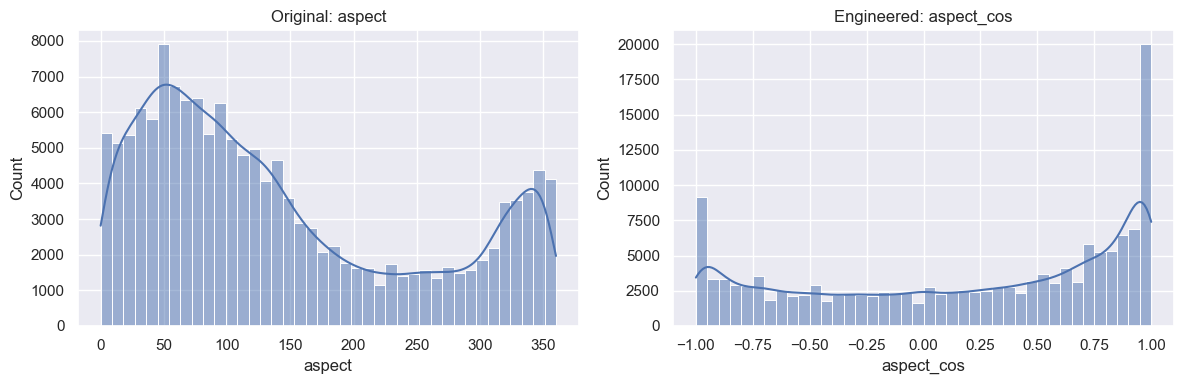

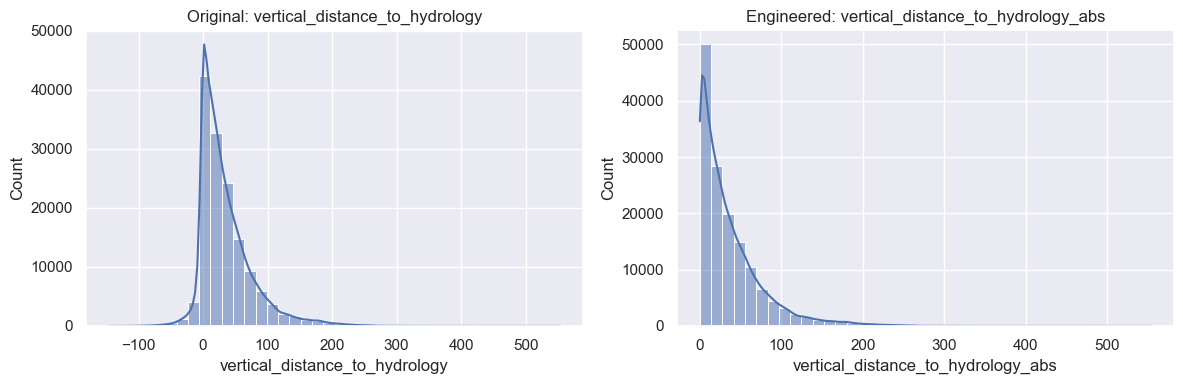

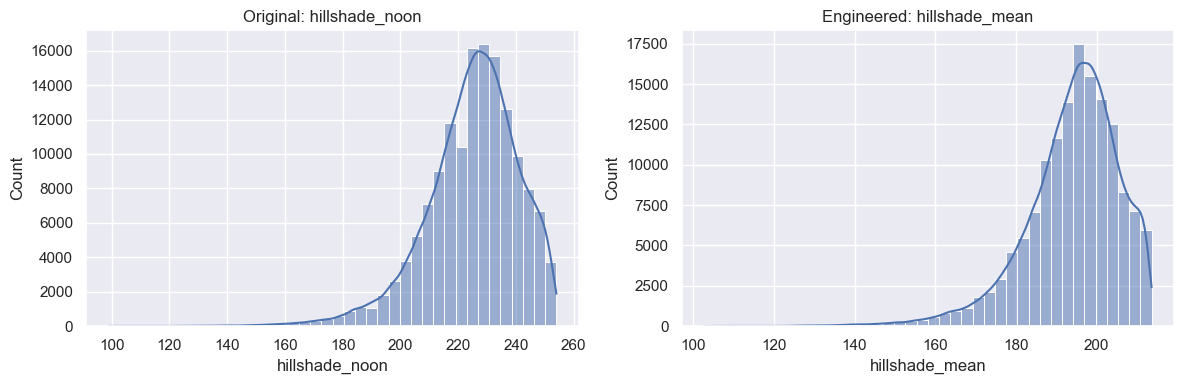

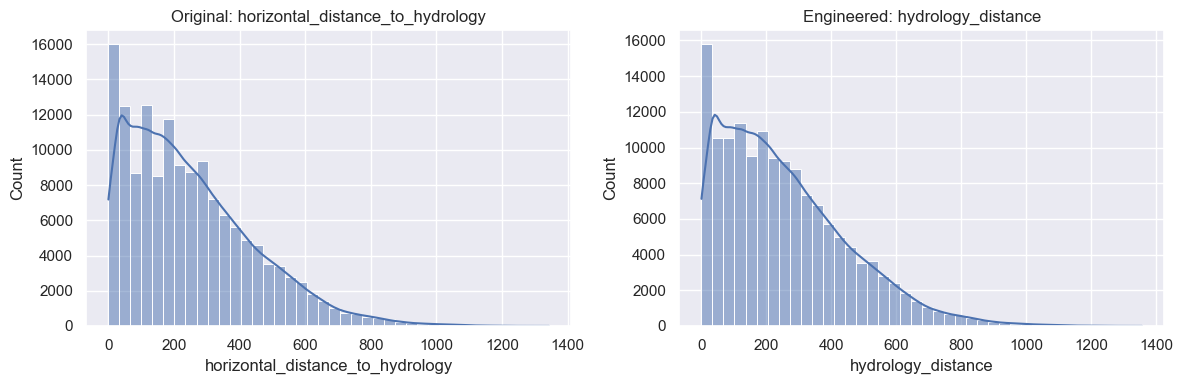

In [13]:
comparison_pairs = [
    ("aspect", "aspect_sin"),
    ("aspect", "aspect_cos"),
    ("vertical_distance_to_hydrology", "vertical_distance_to_hydrology_abs"),
    ("hillshade_noon", "hillshade_mean"),
    ("horizontal_distance_to_hydrology", "hydrology_distance"),
]

comparison_pairs = [
    (a, b)
    for a, b in comparison_pairs
    if a in df_engineered.columns and b in df_engineered.columns
]

for original_col, engineered_col in comparison_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df_engineered[original_col], bins=40, kde=True, ax=axes[0])
    axes[0].set_title(f"Original: {original_col}")

    sns.histplot(df_engineered[engineered_col], bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"Engineered: {engineered_col}")

    plt.tight_layout()
    plt.show()

# Quick Baseline Importance (Optional) (Code)

Train a quick model (RF) to get importance

Save importance table

In [14]:
X = df_engineered.drop(columns=[TARGET_COLUMN]).copy()
Y = df_engineered[TARGET_COLUMN].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", Y.shape)

Feature matrix shape: (145890, 25)
Target shape: (145890,)


In [ ]:
importance_df = get_baseline_features_importance(X, Y)

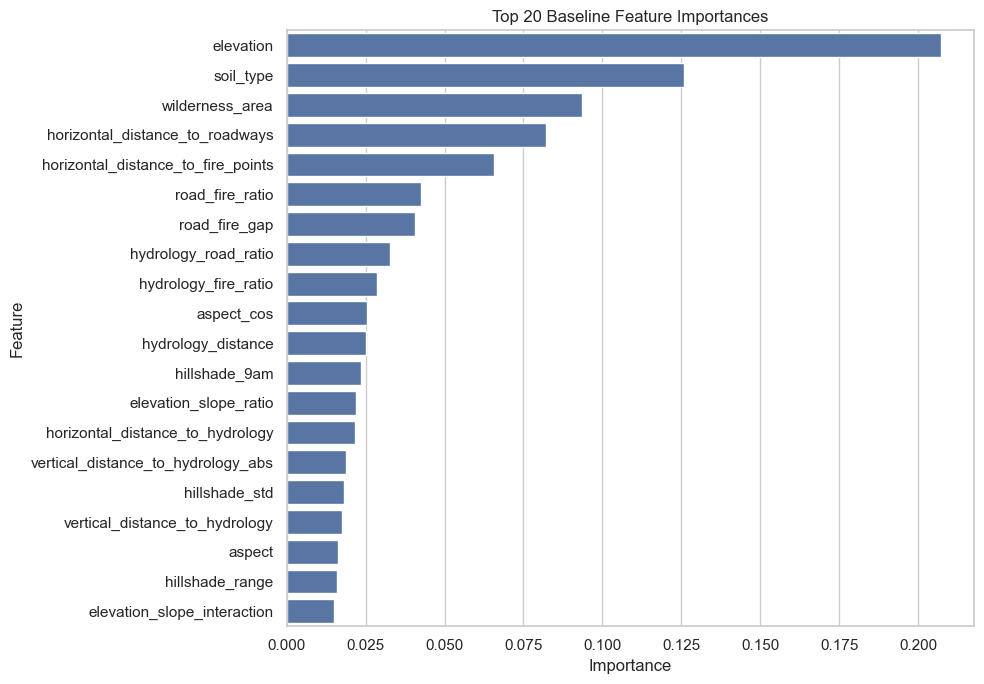

In [24]:
top_n = 20
top_importance = importance_df.head(top_n)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_importance, x="importance", y="feature")
plt.title(f"Top {top_n} Baseline Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Save Final Feature Sets (Code)

Save:

X_train_final, X_test_final

reports/feature_manifest/final_features.txt

reports/feature_manifest/feature_definitions.md

In [27]:
feature_summary_df = df_engineered[new_features].describe().T.reset_index()
feature_summary_df = feature_summary_df.rename(columns={"index": "feature"})
feature_summary_df.to_csv(feature_summary_csv, index=False)

print(f"Saved feature summary to: {feature_summary_csv}")

Saved feature summary to: F:\DATA SCIENCE\Projects\Forest Cover Type Prediction\reports\feature_engineering\feature_summary.csv


In [28]:
importance_df.to_csv(feature_importance_csv, index=False)
print(f"Saved baseline importance report to: {feature_importance_csv}")

Saved baseline importance report to: F:\DATA SCIENCE\Projects\Forest Cover Type Prediction\reports\feature_engineering\baseline_feature_importance.csv


In [30]:
feature_defs_json = docs_dir / "feature_definitions_from_notebook.json"

with open(feature_defs_json, "w", encoding="utf-8") as f:
    json.dump(feature_defs, f, indent=2, ensure_ascii=False)

print(f"Saved feature definitions to: {feature_defs_json}")

Saved feature definitions to: F:\DATA SCIENCE\Projects\Forest Cover Type Prediction\docs\feature_definitions_from_notebook.json


# Notes (Markdown)

What features were added

What features were removed

Why

In [31]:
top_10_features = importance_df.head(10)["feature"].tolist()

report_lines = [
    "# Feature Engineering Report",
    "",
    "## Dataset Shapes",
    "",
    f"- Original shape: {df.shape}",
    f"- Engineered shape: {df_engineered.shape}",
    f"- Number of engineered features: {len(new_features)}",
    "",
    "## Engineered Features",
    "",
]

for feat in new_features:
    definition = feature_defs.get(feat, "Definition not found.")
    report_lines.append(f"- **{feat}**: {definition}")

report_lines.extend([
    "",
    "## Top 10 Baseline Important Features",
    "",
])

for feat in top_10_features:
    score = importance_df.loc[importance_df["feature"] == feat, "importance"].iloc[0]
    report_lines.append(f"- **{feat}**: {score:.6f}")

report_lines.extend([
    "",
    "## Notes",
    "",
    "- Baseline feature importance is only an early ranking signal.",
    "- Final feature selection should be validated in the dedicated selection phase.",
    "- Engineered dataset has been saved for downstream modeling.",
])

NOTEBOOK_REPORT_MD.write_text("\n".join(report_lines), encoding="utf-8")

print(f"Saved notebook report to: {NOTEBOOK_REPORT_MD}")

Saved notebook report to: F:\DATA SCIENCE\Projects\Forest Cover Type Prediction\reports\feature_engineering\feature_engineering_report.md
